# HW_6: Сравнение бустингов на задаче предсказания оттока

Цель: определить, какой алгоритм бустинга работает лучше на задаче бинарной классификации оттока.

Сравниваем 4 модели:
- `GradientBoostingClassifier` (sklearn)
- `XGBClassifier` (XGBoost)
- `CatBoostClassifier` (CatBoost)
- `LGBMClassifier` (LightGBM)

Основная метрика: **ROC-AUC**.

## 1) Настройка окружения и загрузка данных из `hw_6`

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

candidate_paths = [
    Path("train-109924-d0d60f.csv"),
    Path("hw_6/train-109924-d0d60f.csv"),
]

for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Could not find train-109924-d0d60f.csv")

df = pd.read_csv(DATA_PATH)

# Приводим название таргета к Churn для единого стиля задания
if "Activity" in df.columns and "Churn" not in df.columns:
    df = df.rename(columns={"Activity": "Churn"})

print(df.shape)
df.head()

(3751, 1777)


,Churn,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26,D27,D28,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38,D39,D40,D41,D42,D43,D44,D45,D46,D47,D48,D49,D50,D51,D52,D53,D54,D55,D56,D57,D58,D59,D60,D61,D62,D63,D64,D65,D66,D67,D68,D69,D70,D71,D72,D73,D74,D75,D76,D77,D78,D79,D80,D81,D82,D83,D84,D85,D86,D87,D88,D89,D90,D91,D92,D93,D94,D95,D96,D97,D98,D99,...,D1677,D1678,D1679,D1680,D1681,D1682,D1683,D1684,D1685,D1686,D1687,D1688,D1689,D1690,D1691,D1692,D1693,D1694,D1695,D1696,D1697,D1698,D1699,D1700,D1701,D1702,D1703,D1704,D1705,D1706,D1707,D1708,D1709,D1710,D1711,D1712,D1713,D1714,D1715,D1716,D1717,D1718,D1719,D1720,D1721,D1722,D1723,D1724,D1725,D1726,D1727,D1728,D1729,D1730,D1731,D1732,D1733,D1734,D1735,D1736,D1737,D1738,D1739,D1740,D1741,D1742,D1743,D1744,D1745,D1746,D1747,D1748,D1749,D1750,D1751,D1752,D1753,D1754,D1755,D1756,D1757,D1758,D1759,D1760,D1761,D1762,D1763,D1764,D1765,D1766,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,0.243144,0.187856,0.0000,0.000000,0.069000,0.362012,0.301773,0.597930,0.190813,0.107219,0.070500,0.00717,0.137931,1,0.00,0.496683,0.753131,1,1,0.000000,0.262919,0.077200,0.082700,0.200590,0.00000,0.000000,0.0,0.0,0.162383,0.150153,0.000000,0.0,0.0,0.000000,0.092000,0.057300,0.426576,0.234822,0.050200,0.000000,0.833333,0,1.000000,0.121520,0.0000,0.000000,0.000000,0.035100,0.133438,0.0,0.0000,0.011700,0.00000,0.000000,0.0,0.034600,0.027100,0.361513,0.000000,0.075300,0.611301,0.000000,0,0.263109,0.189941,0.000000,0.083500,0.166667,0.01350,0.285714,0.015700,0.0,0.0,0.222222,0.045500,0.0000,0.027800,0.307537,0.06940,0.604357,0.340425,0.451980,0.000000,0.047600,0,0.000335,0.066700,0.000000,0.0,0.599647,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,0.106480,0.101382,0.1875,0.193548,0.131001,0.350206,0.187419,0.762669,0.180473,0.329962,0.107681,0.01950,0.206897,0,0.75,0.449869,0.720484,0,0,0.666667,0.099400,0.289240,0.216710,0.100295,0.16958,0.235294,0.0,0.0,0.119104,0.075100,0.000000,0.0,0.0,0.199919,0.312883,0.276016,0.647681,0.286386,0.324514,0.156568,1.000000,0,0.578947,0.268620,0.0634,0.190839,0.000000,0.368455,0.191837,0.0,0.0689,0.175271,0.28171,0.254301,0.0,0.362117,0.161739,0.161839,0.051000,0.268761,0.806448,0.264825,0,0.000000,0.280782,0.187546,0.282772,0.333333,0.07430,0.428571,0.153405,0.0,0.0,0.555556,0.180608,0.0209,0.154395,0.433171,0.29509,0.454201,0.316492,0.313217,0.052600,0.000000,1,0.017800,0.366667,0.105263,0.4,0.671557,...,1,0,0,1,1,1,0,1,0,0,0,0,1,1,0,0,0,1,1,0,1,0,1,1,0,1,0,0,1,1,0,1,0,1,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,1,0,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,1,0,1,1,0,0,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,0.352308,0.193548,0.1250,0.000000,0.068900,0.574628,0.283327,0.510633,0.184480,0.073300,0.061600,0.00566,0.000000,1,0.00,0.486610,0.803577,0,1,0.000000,0.428659,0.032400,0.072400,0.000000,0.03930,0.000000,0.0,0.0,0.076100,0.225229,0.000000,0.0,0.0,0.066600,0.000000,0.079100,0.298171,0.212155,0.051200,0.000000,0.750000,1,1.000000,0.000000,0.0211,0.063900,0.000000,0.017600,0.000000,0.0,0.0275,0.070900,0.07180,0.000000,0.0,0.017300,0.000000,0.156408,0.069700,0.024700,0.517376,0.074500,0,0.000000,0.153632,0.039600,0.031900,0.000000,0.00676,0.285714,0.000000,0.0,0.0,0.111111,0.022700,0.0000,0.009880,0.351472,0.04840,0.608789,0.342316,0.466053,0.052600,0.047600,0,0.000069,0.066700,0.000000,0.0,0.500745,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.72

## 2) Первичный обзор данных и проверка типов

In [3]:
print("Shape:", df.shape)
print("\nDtypes (top 20):")
print(df.dtypes.head(20))
print("\nInfo:")
print(df.info())

display(df.describe(include="all").T.head(20))

n_unique = df.nunique().sort_values(ascending=False)
print("\nTop-20 признаков по числу уникальных значений:")
display(n_unique.head(20).to_frame("n_unique"))

Shape: (3751, 1777)

Dtypes (top 20):
Churn      int64
D1       float64
D2       float64
D3       float64
D4       float64
D5       float64
D6       float64
D7       float64
D8       float64
D9       float64
D10      float64
D11      float64
D12      float64
D13      float64
D14      float64
D15      float64
D16      float64
D17      float64
D18      float64
D19      float64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3751 entries, 0 to 3750
Columns: 1777 entries, Churn to D1776
dtypes: float64(942), int64(835)
memory usage: 50.9 MB
None


,count,mean,std,min,25%,50%,75%,max
Churn,3751.0,0.542255,0.498278,0.000000,0.000000,1.000000,1.000000,1.000000
D1,3751.0,0.076948,0.079989,0.000000,0.033300,0.066700,0.100000,1.000000
D2,3751.0,0.592436,0.105860,0.282128,0.517811,0.585989,0.668395,0.964381
D3,3751.0,0.068142,0.078414,0.000000,0.000000,0.050000,0.100000,0.950000
D4,3751.0,0.038990,0.115885,0.000000,0.000000,0.000000,0.000000,1.000000
D5,3751.0,0.212112,0.102592,0.002630,0.138118,0.190926,0.261726,1.000000
D6,3751.0,0.686653,0.078702,0.137873,0.625627,0.674037,0.740663,0.994735
D7,3751.0,0.274713,0.090017,0.006130,0.207374,0.277845,0.335816,0.790831
D8,3751.0,0.455133,0.162731,0.000000,0.378062,0.499942,0.569962,0.989870
D9,3751.0,0.749517,0.071702,0.275590,0.707339,0.738961,0.788177,1.000000



Top-20 признаков по числу уникальных значений:


,n_unique
D17,3749
D9,3741
D6,3732
D10,3692
D7,3685
D15,3682
D30,3671
D89,3658
D105,3640
D106,3638


## 3) EDA: пропуски, дисбаланс таргета, базовые распределения

Пропуски (топ-20):


,missing_cnt
Churn,0
D1,0
D2,0
D3,0
D4,0
D5,0
D6,0
D7,0
D8,0
D9,0


Количество дубликатов: 0


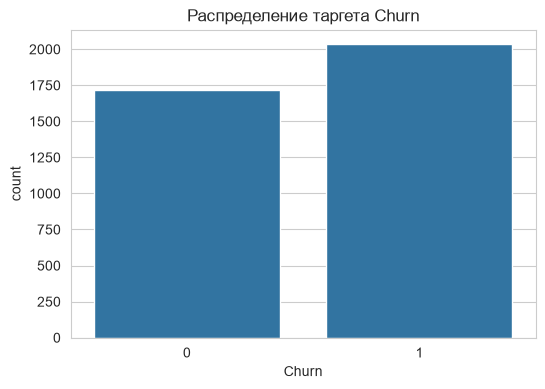

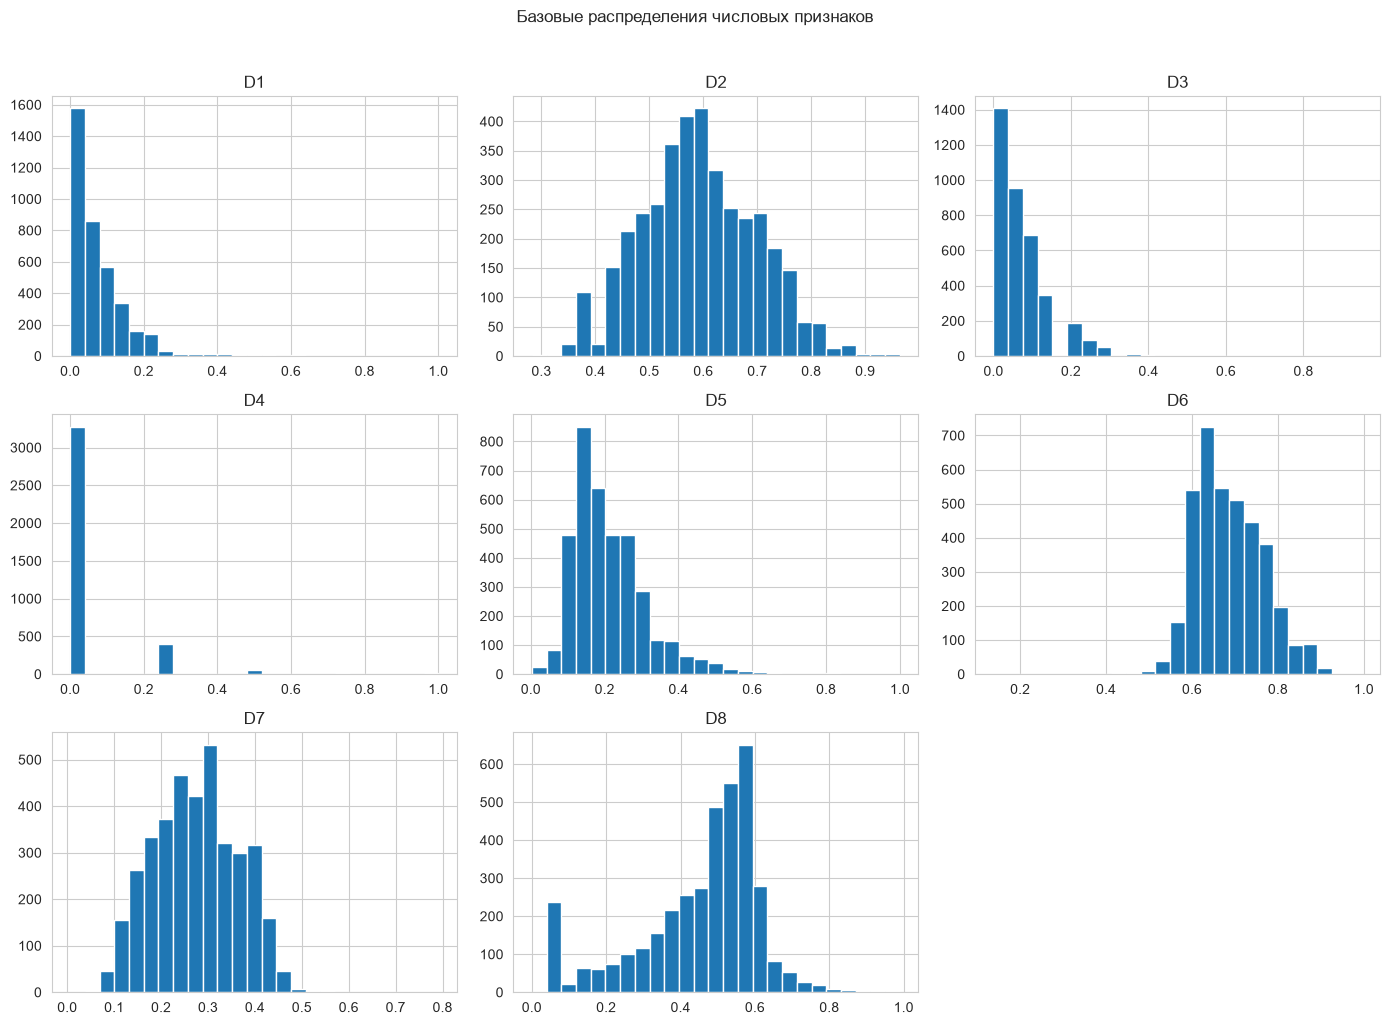

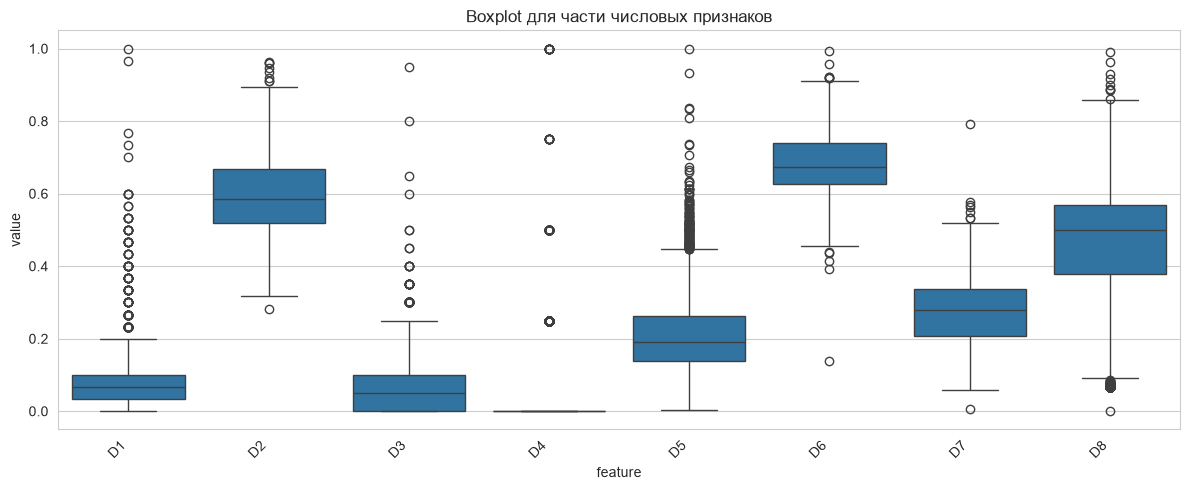

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски (топ-20):")
display(missing.head(20).to_frame("missing_cnt"))

dup_cnt = df.duplicated().sum()
print(f"Количество дубликатов: {dup_cnt}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Распределение таргета Churn")
plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_eda = [c for c in num_cols if c != "Churn"][:8]

if num_cols_eda:
    df[num_cols_eda].hist(figsize=(14, 10), bins=25)
    plt.suptitle("Базовые распределения числовых признаков", y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    melted = df[num_cols_eda].melt(var_name="feature", value_name="value")
    sns.boxplot(data=melted, x="feature", y="value")
    plt.xticks(rotation=45, ha="right")
    plt.title("Boxplot для части числовых признаков")
    plt.tight_layout()
    plt.show()

## 4) EDA: зависимости признаков с `Churn`

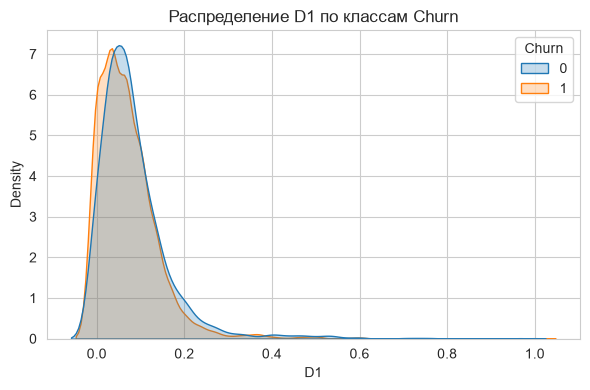

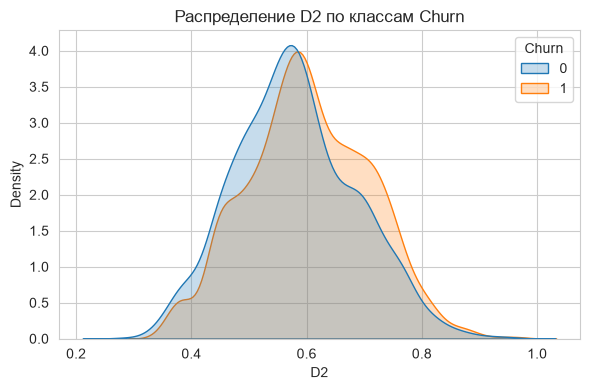

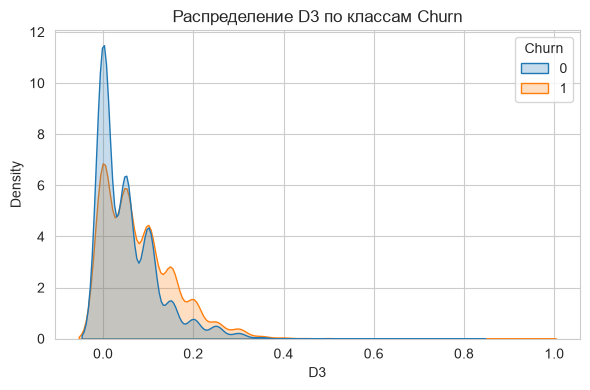

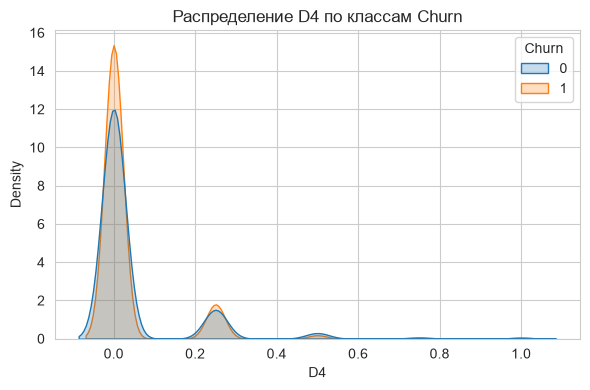

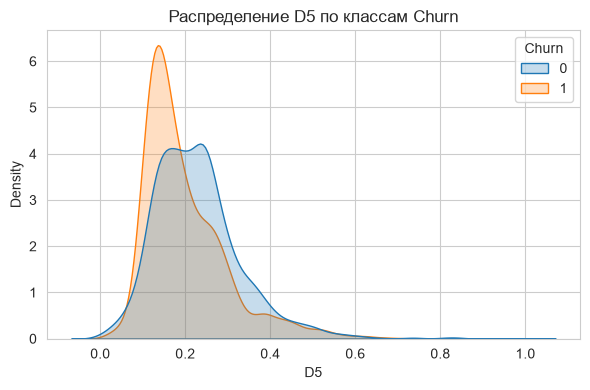

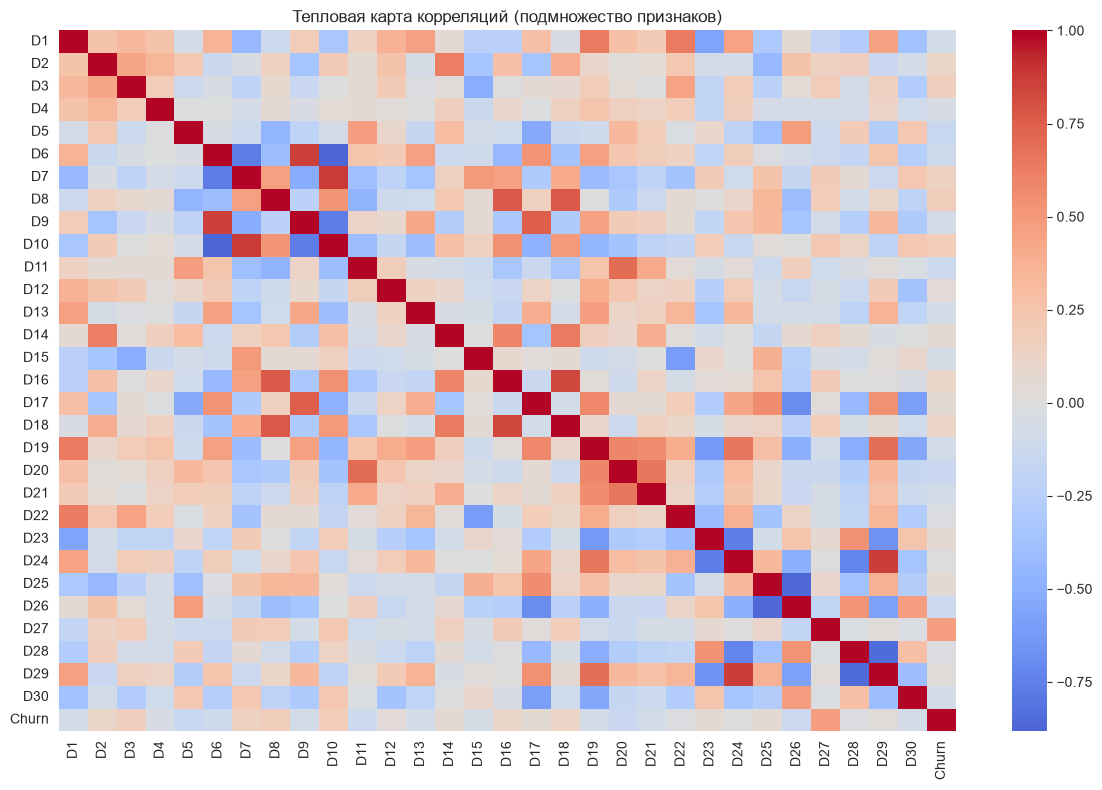

Churn,0,1
D1,0.084469,0.070599
D2,0.579853,0.603059
D3,0.053873,0.080187
D4,0.044554,0.034292
D5,0.228685,0.198121
D6,0.695750,0.678974
D7,0.261290,0.286043
D8,0.424633,0.480880
D9,0.755583,0.744396
D10,0.251676,0.286227


In [5]:
key_num = [c for c in ["D1", "D2", "D3", "D4", "D5"] if c in df.columns]
for col in key_num:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, fill=True, alpha=0.25)
    plt.title(f"Распределение {col} по классам Churn")
    plt.tight_layout()
    plt.show()

corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "Churn"][:30]
if corr_cols:
    plt.figure(figsize=(12, 8))
    corr = df[corr_cols + ["Churn"]].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Тепловая карта корреляций (подмножество признаков)")
    plt.tight_layout()
    plt.show()

# Агрегация средних значений признаков по классам
agg_preview = df.groupby("Churn")[corr_cols[:10]].mean().T
display(agg_preview.head(10))

## 5) Preprocessing: очистка, LabelEncoder для категориальных признаков

In [6]:
df_prep = df.copy()

# Таргет должен быть бинарным 0/1
if df_prep["Churn"].dtype == "object":
    df_prep["Churn"] = df_prep["Churn"].map({"No": 0, "Yes": 1})

# Числовые пропуски заполняем медианами
num_cols_all = [c for c in df_prep.columns if c != "Churn" and pd.api.types.is_numeric_dtype(df_prep[c])]
for c in num_cols_all:
    if df_prep[c].isna().any():
        df_prep[c] = df_prep[c].fillna(df_prep[c].median())

# На случай отсутствия категориальных: создаем 2 осмысленных категориальных фичи биннингом
if "tenure_group" not in df_prep.columns and "D1" in df_prep.columns:
    df_prep["tenure_group"] = pd.cut(df_prep["D1"], bins=4, labels=["short", "medium", "long", "very_long"])
if "charge_group" not in df_prep.columns and "D2" in df_prep.columns:
    df_prep["charge_group"] = pd.qcut(df_prep["D2"].rank(method="first"), q=4, labels=["low", "mid_low", "mid_high", "high"])

cat_cols = [c for c in df_prep.columns if c != "Churn" and df_prep[c].dtype == "object"]
cat_cols += [c for c in df_prep.columns if c != "Churn" and str(df_prep[c].dtype).startswith("category")]
cat_cols = sorted(list(set(cat_cols)))

label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df_prep[c] = df_prep[c].astype(str).fillna("Missing")
    df_prep[c] = le.fit_transform(df_prep[c])
    label_encoders[c] = le

print(f"Encoded categorical columns: {len(cat_cols)}")
print(cat_cols[:20])
print("Shape after preprocessing:", df_prep.shape)

Encoded categorical columns: 2
['charge_group', 'tenure_group']
Shape after preprocessing: (3751, 1779)


## 6) Feature Engineering: новые признаки и удаление нерелевантных колонок

In [7]:
df_fe = df_prep.copy()

feature_cols = [c for c in df_fe.columns if c != "Churn"]

# Несколько производных признаков
if all(c in df_fe.columns for c in ["D1", "D2"]):
    df_fe["avg_charge_proxy"] = df_fe["D2"] / (df_fe["D1"] + 1e-6)
if all(c in df_fe.columns for c in ["D3", "D4", "D5"]):
    df_fe["service_intensity"] = df_fe[["D3", "D4", "D5"]].mean(axis=1)

# Признаки почти без вариативности удаляем
low_var_cols = []
for c in feature_cols:
    if c in df_fe.columns and df_fe[c].nunique() <= 1:
        low_var_cols.append(c)

if low_var_cols:
    df_fe = df_fe.drop(columns=low_var_cols)

print("Shape after FE:", df_fe.shape)
print("Dropped low-variance columns:", len(low_var_cols))

Shape after FE: (3751, 1781)
Dropped low-variance columns: 0


## 7) Train/Test split и подготовка матриц признаков

In [8]:
X = df_fe.drop(columns=["Churn"])
y = df_fe["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cat_features_idx = [i for i, c in enumerate(X.columns) if c in cat_cols]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Target distribution in train:")
print(y_train.value_counts(normalize=True))

X_train: (3000, 1780) X_test: (751, 1780)
Target distribution in train:
Churn
1    0.542333
0    0.457667
Name: proportion, dtype: float64


## 8) Модели бустинга “из коробки”: sklearn, XGBoost, CatBoost, LightGBM

In [9]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_te, proba),
        "accuracy": accuracy_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }

baseline_models = {
    "sklearn_gb": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
    ),
    "catboost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        iterations=300,
        learning_rate=0.1,
        depth=6,
    ),
    "lightgbm": LGBMClassifier(
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        verbosity=-1,
    ),
}

baseline_results = []
for name, model in baseline_models.items():
    baseline_results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

baseline_df = pd.DataFrame(baseline_results).sort_values("roc_auc", ascending=False)
display(baseline_df)

,model,roc_auc,accuracy,f1,precision,recall
2,catboost,0.867486,0.782956,0.804322,0.786385,0.823096
3,lightgbm,0.865251,0.789614,0.811456,0.788863,0.835381
1,xgboost,0.865036,0.785619,0.804848,0.794258,0.815725
0,sklearn_gb,0.840441,0.758988,0.786808,0.755656,0.820639


## 9) Оценка качества на отложенной выборке и текущий лидер

Лидер baseline:
model        catboost
roc_auc      0.867486
accuracy     0.782956
f1           0.804322
precision    0.786385
recall       0.823096
Name: 2, dtype: object


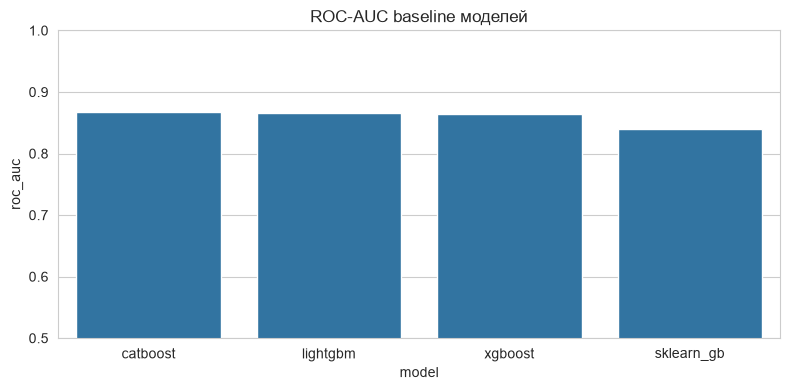

In [10]:
leader_baseline = baseline_df.iloc[0]
print("Лидер baseline:")
print(leader_baseline)

plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_df, x="model", y="roc_auc")
plt.ylim(0.5, 1.0)
plt.title("ROC-AUC baseline моделей")
plt.tight_layout()
plt.show()

## 10) Тюнинг гиперпараметров на кросс-валидации для 4 моделей

In [11]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "sklearn_gb": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.7, 0.9, 1.0],
            "max_features": ["sqrt", None],
        },
    },
    "xgboost": {
        "model": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        "params": {
            "n_estimators": [200, 400],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 4, 6],
            "subsample": [0.7, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.9, 1.0],
        },
    },
    "catboost": {
        "model": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
        "params": {
            "iterations": [200, 400, 600],
            "learning_rate": [0.03, 0.05, 0.1],
            "depth": [4, 6, 8],
            "subsample": [0.7, 0.9, 1.0],
        },
    },
    "lightgbm": {
        "model": LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
        "params": {
            "n_estimators": [200, 400, 600],
            "learning_rate": [0.03, 0.05, 0.1],
            "num_leaves": [15, 31, 63],
            "subsample": [0.7, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.9, 1.0],
        },
    },
}

best_models = {}
cv_results = []

for model_name, cfg in search_spaces.items():
    print(f"Tuning: {model_name}")
    search = RandomizedSearchCV(
        estimator=cfg["model"],
        param_distributions=cfg["params"],
        n_iter=10,
        scoring="roc_auc",
        n_jobs=-1,
        cv=cv,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    cv_results.append(
        {
            "model": model_name,
            "best_cv_roc_auc": search.best_score_,
            "best_params": search.best_params_,
        }
    )

cv_results_df = pd.DataFrame(cv_results).sort_values("best_cv_roc_auc", ascending=False)
display(cv_results_df)

Tuning: sklearn_gb
Tuning: xgboost
Tuning: catboost
Tuning: lightgbm


,model,best_cv_roc_auc,best_params
3,lightgbm,0.862313,"{'subsample': 0.7, 'num_leaves': 63, 'n_estima..."
1,xgboost,0.862258,"{'subsample': 1.0, 'n_estimators': 200, 'max_d..."
2,catboost,0.861553,"{'subsample': 0.9, 'learning_rate': 0.1, 'iter..."
0,sklearn_gb,0.857772,"{'subsample': 0.7, 'n_estimators': 300, 'max_f..."


## 11) Финальная проверка tuned-моделей и итоговый рейтинг

Baseline vs Tuned summary:


,model,roc_auc_baseline,accuracy_baseline,f1_baseline,precision_baseline,recall_baseline,roc_auc_tuned,accuracy_tuned,f1_tuned,precision_tuned,recall_tuned,roc_auc_gain
1,lightgbm,0.865251,0.789614,0.811456,0.788863,0.835381,0.871486,0.785619,0.807186,0.787383,0.828010,0.006235
2,xgboost,0.865036,0.785619,0.804848,0.794258,0.815725,0.868008,0.781625,0.803828,0.783217,0.825553,0.002971
0,catboost,0.867486,0.782956,0.804322,0.786385,0.823096,0.867279,0.773635,0.796651,0.776224,0.818182,-0.000207
3,sklearn_gb,0.840441,0.758988,0.786808,0.755656,0.820639,0.856494,0.777630,0.800478,0.779070,0.823096,0.016053



Итоговый победитель:
model        lightgbm
roc_auc      0.871486
accuracy     0.785619
f1           0.807186
precision    0.787383
recall        0.82801
Name: 3, dtype: object


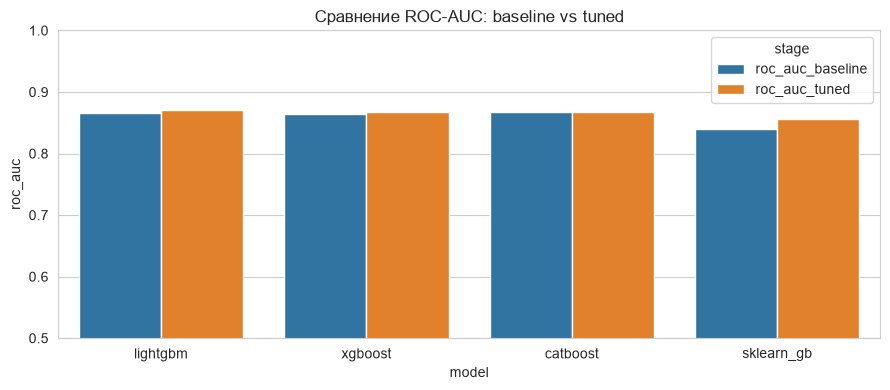

In [12]:
tuned_results = []
for name, model in best_models.items():
    tuned_results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

tuned_df = pd.DataFrame(tuned_results).sort_values("roc_auc", ascending=False)

summary = baseline_df.merge(
    tuned_df,
    on="model",
    suffixes=("_baseline", "_tuned"),
)
summary["roc_auc_gain"] = summary["roc_auc_tuned"] - summary["roc_auc_baseline"]
summary = summary.sort_values("roc_auc_tuned", ascending=False)

print("Baseline vs Tuned summary:")
display(summary)

winner = tuned_df.iloc[0]
print("\nИтоговый победитель:")
print(winner)

plt.figure(figsize=(9, 4))
plot_df = summary[["model", "roc_auc_baseline", "roc_auc_tuned"]].melt(
    id_vars="model", var_name="stage", value_name="roc_auc"
)
sns.barplot(data=plot_df, x="model", y="roc_auc", hue="stage")
plt.ylim(0.5, 1.0)
plt.title("Сравнение ROC-AUC: baseline vs tuned")
plt.tight_layout()
plt.show()